# **0. Data and Library imports**

In [1]:
import pandas as pd
import matplotlib as mp
import numpy as np

customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_payments = pd.read_csv("olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_name_translation = pd.read_csv("product_category_name_translation.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'product_category_name_translation.csv'

# **1. Basic Exploratory Data Analysis (EDA) and Data Cleaning:**

## A- Orders:

In [ ]:
orders.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


In [ ]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


We can see that there are no repetition of customers, meaning that every order has a different buyer.

In [ ]:
orders["order_status"].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

We can see that there are many diferent order status, meaning not every order has been already delivered, so we should expect nulls in some date columns. I will check that the dates columns are consistent with this status and between them, and will also look for delivery duration outliers.

In [ ]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [ ]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

In [ ]:
#Status --> delivered 
print("Delivered:", int(((orders["order_status"] == "delivered") & (orders[["order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"]].isnull().any(axis=1))).sum()))

#Status --> invoiced
print("Invoiced:", int(((orders["order_status"] == "invoiced") & (~(orders[["order_purchase_timestamp", "order_approved_at"]].notnull().all(axis=1)) | orders[["order_delivered_carrier_date", "order_delivered_customer_date"]].notnull().any(axis=1))).sum()))
#Status --> Shipped
print("Shipped:", int(((orders["order_status"] == "shipped") & (~(orders[["order_approved_at", "order_delivered_carrier_date"]].notnull().all(axis=1)) | orders["order_delivered_customer_date"].notnull())).sum()))

#Status --> processing
print("Processing:", int(((orders["order_status"] == "processing") & (~(orders[["order_purchase_timestamp", "order_approved_at"]].notnull().all(axis=1)) | orders[["order_delivered_carrier_date", "order_delivered_customer_date"]].notnull().any(axis=1))).sum()))

#Status --> unavailable
print("Unavailable:", int(((orders["order_status"] == "unavailable") & (~(orders[["order_purchase_timestamp", "order_approved_at"]].notnull().all(axis=1)) | orders[["order_delivered_carrier_date", "order_delivered_customer_date"]].notnull().any(axis=1))).sum()))

#Status --> canceled
print("Canceled:", int(((orders["order_status"] == "canceled") & (orders["order_purchase_timestamp"].isnull())).sum()))

#Status --> created
print("Created:", int(((orders["order_status"] == "created") & (~(orders[["order_purchase_timestamp"]].notnull().all(axis=1)) | orders[["order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"]].notnull().any(axis=1))).sum()))

#Status --> approved
print("Approved:", int(((orders["order_status"] == "approved") & (~(orders[["order_purchase_timestamp", "order_approved_at"]].notnull().all(axis=1)) | orders[["order_delivered_carrier_date", "order_delivered_customer_date"]].notnull().any(axis=1))).sum()))

Delivered: 23
Invoiced: 0
Shipped: 0
Processing: 0
Unavailable: 0
Canceled: 0
Created: 0
Approved: 0


Every order state registration, except some "delivered" ones, is consistent when looking at their date columns. In the next step, I will analyze the Delivered cases.

In [ ]:
orders[(orders["order_status"] == "delivered") & (orders[["order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"]].isnull().any(axis=1))]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22


There isn'a logical explanation for these null values, so most likely they were caused by a system or input error. Since these nulls are only 28 values out of 100k, they are no representative, so I will delete them.

In [ ]:
orders = orders[~((orders["order_status"] == "delivered") & (orders[["order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"]].isnull().any(axis=1)))]

In [ ]:
# order_approved_at can't happen before order_purchase_timestamp
print("Approved before purchase:", int((orders["order_approved_at"] < orders["order_purchase_timestamp"]).sum()))

# order_delivered_carrier_date can't happen before order_approved_at
print("Carrier before approved:", int((orders["order_delivered_carrier_date"] < orders["order_approved_at"]).sum()))

# order_delivered_customer_date can't happen before order_delivered_carrier_date
print("Customer before carrier:", int((orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"]).sum()))

Approved before purchase: 0
Carrier before approved: 1359
Customer before carrier: 23


These registrations will be flaged.

In [ ]:
orders["fecha_inconsistente"] = (
    (orders["order_delivered_carrier_date"] < orders["order_approved_at"]) |
    (orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"])
)

## B- Customers:

In [ ]:
customers.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


In [ ]:
customers.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [ ]:
customers.dtypes

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [ ]:
print("customer_id nulls:", int(customers["customer_id"].isnull().sum()))
print("customer_city nulls:", int(customers["customer_city"].isnull().sum()))
print("customer_state nulls:", int(customers["customer_state"].isnull().sum()))

customer_id nulls: 0
customer_city nulls: 0
customer_state nulls: 0


There are no repetitions of customer_id and no critical nulls. Everythings looks clean.

## C- Products:

In [ ]:
products.head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57.0,163.0,1.0,400.0,27.0,13.0,17.0
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36.0,1156.0,1.0,600.0,17.0,10.0,12.0


In [ ]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
print ("Product_photo_qty nulls:", products["product_photos_qty"].isnull().sum())
print ("product_weight_g nulls:", products["product_weight_g"].isnull().sum())
print ("Product_length_cm nulls:", products["product_length_cm"].isnull().sum())
print ("Product_height_cm nulls:", products["product_height_cm"].isnull().sum() )
print ("Product_width_cm nulls: ", products["product_width_cm"].isnull().sum())
print ("Product_category_name nulls:", products["product_category_name"].isnull().sum())


Product_photo_qty nulls: 610
product_weight_g nulls: 2
Product_length_cm nulls: 2
Product_height_cm nulls: 2
Product_width_cm nulls:  2
Product_category_name nulls: 610


In [ ]:
products[(products["product_weight_g"].isnull())]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
products[(products["product_category_name"].isnull())& products["product_photos_qty"].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


There are 610 entries that have no detaill (nulls): No category, no description and no photos. This lack of category may cause inconvinience in future steps when we need to segment the data to anlalyze by category, so I'll replace this null values with "Other".

Regarding the 2 nulls in the detaill columns, I'll leave them like that as those variables won't add value to our future analysis.

In [ ]:
products["product_category_name"]= products["product_category_name"].fillna("other")
products["product_category_name"].unique()

array(['perfumaria', 'artes', 'esporte_lazer', 'bebes',
       'utilidades_domesticas', 'instrumentos_musicais', 'cool_stuff',
       'moveis_decoracao', 'eletrodomesticos', 'brinquedos',
       'cama_mesa_banho', 'construcao_ferramentas_seguranca',
       'informatica_acessorios', 'beleza_saude', 'malas_acessorios',
       'ferramentas_jardim', 'moveis_escritorio', 'automotivo',
       'eletronicos', 'fashion_calcados', 'telefonia', 'papelaria',
       'fashion_bolsas_e_acessorios', 'pcs', 'casa_construcao',
       'relogios_presentes', 'construcao_ferramentas_construcao',
       'pet_shop', 'eletroportateis', 'agro_industria_e_comercio',
       'other', 'moveis_sala', 'sinalizacao_e_seguranca', 'climatizacao',
       'consoles_games', 'livros_interesse_geral',
       'construcao_ferramentas_ferramentas',
       'fashion_underwear_e_moda_praia', 'fashion_roupa_masculina',
       'moveis_cozinha_area_de_servico_jantar_e_jardim',
       'industria_comercio_e_negocios', 'telefonia_fixa',

## D- Sellers:

In [ ]:
sellers.head(10)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
5,c240c4061717ac1806ae6ee72be3533b,20920,rio de janeiro,RJ
6,e49c26c3edfa46d227d5121a6b6e4d37,55325,brejao,PE
7,1b938a7ec6ac5061a66a3766e0e75f90,16304,penapolis,SP
8,768a86e36ad6aae3d03ee3c6433d61df,1529,sao paulo,SP
9,ccc4bbb5f32a6ab2b7066a4130f114e3,80310,curitiba,PR


In [ ]:
sellers.describe(include="all")

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


In [ ]:
print("seller_id nulls:", int(sellers["seller_id"].isnull().sum()))
print("seller_ city nulls:", int(sellers["seller_city"].isnull().sum()))
print("seller_state nulls:", int(sellers["seller_state"].isnull().sum()))

seller_id nulls: 0
seller_ city nulls: 0
seller_state nulls: 0


All seller id's are unique, as they should, and no critical nulls. 

## E- Geolocation:

In [ ]:
geolocation.head(10)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
5,1012,-23.547762,-46.635361,são paulo,SP
6,1047,-23.546273,-46.641225,sao paulo,SP
7,1013,-23.546923,-46.634264,sao paulo,SP
8,1029,-23.543769,-46.634278,sao paulo,SP
9,1011,-23.547640,-46.636032,sao paulo,SP


In [ ]:
geolocation.describe(include="all")

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


In [ ]:
print("geolocation_city nulls:", int(geolocation["geolocation_city"].isnull().sum()))
print("geolocation_state nulls:", int(geolocation["geolocation_state"].isnull().sum()))

geolocation_city nulls: 0
geolocation_state nulls: 0


In [ ]:
geolocation.dtypes

geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

No critical nulls and all data types are okay.

## F- Order items:

In [ ]:
order_items.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


In [ ]:
order_items.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


We can notice that we will certainly found price and freig_value outliers, as max is too far from std and meanwhile these being pretty similar, meaning the data is not very disperse. In the next steps, we will double click on these cases.

I also see that the min value of freight_value is 0. This  most means that some orders have costless shipping, which makes sense for 3 probable reasons:

    1- Business dynamics: Olist may be offering costless shipping in some situations, like when shipping expensive orders or as part of promotions.
    2- Canceled orders: Many orders might been cancelled before the shipment was processed.
    3- Digital services: Many products selled by this marketplace are digital services (e.g. music, telefonic services), which means there is no need for shipment. 
    
We will certainly see this hypothesis confirmed during the EDA phase and we won't be considering freight_value = 0 as outliers.

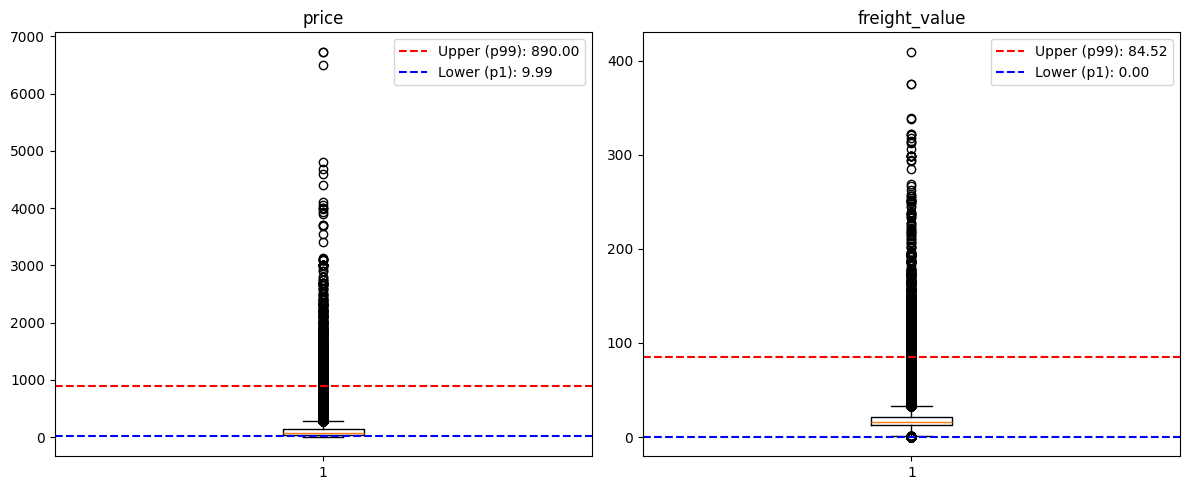

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

configs = {
    "price": {"lower": order_items["price"].quantile(0.01), "upper": order_items["price"].quantile(0.99)},
    "freight_value": {"lower": 0, "upper": order_items["freight_value"].quantile(0.99)}
}

for ax, col in zip(axes, ["price", "freight_value"]):
    lower = configs[col]["lower"]
    upper = configs[col]["upper"]
    
    ax.boxplot(order_items[col], vert=True)
    ax.axhline(upper, color="red", linestyle="--", label=f"Upper (p99): {upper:.2f}")
    ax.axhline(lower, color="blue", linestyle="--", label=f"Lower (p1): {lower:.2f}")
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
for col, lower, upper in [
    ("price", order_items["price"].quantile(0.01), order_items["price"].quantile(0.99)),
    ("freight_value", 0, order_items["freight_value"].quantile(0.99))
]:
    outliers = ((order_items[col] < lower) | (order_items[col] > upper)).sum()
    pct = outliers / len(order_items) * 100
    print(f"{col}: {outliers} outliers ({pct:.2f}%)")

price: 2197 outliers (1.95%)
freight_value: 1124 outliers (1.00%)


As the outliers aren't a big portion of the data, we won't be deleting them. If so, we would lose the remaining valuable data of the table. We will flag this outliers.

In [ ]:
order_items["outlier_price"] = (
    (order_items["price"] < order_items["price"].quantile(0.01)) |
    (order_items["price"] > order_items["price"].quantile(0.99))
)

order_items["outlier_freight"] = (
    order_items["freight_value"] > order_items["freight_value"].quantile(0.99)
)

In [ ]:
print("order_id nulls:", int(order_items["order_id"].isnull().sum()))
print("product_id nulls:", int(order_items["product_id"].isnull().sum()))
print("seller_id nulls:", int(order_items["seller_id"].isnull().sum()))
print("price nulls:", int(order_items["price"].isnull().sum()))
print("freigt_value nulls:", int(order_items["freight_value"].isnull().sum()))

order_id nulls: 0
product_id nulls: 0
seller_id nulls: 0
price nulls: 0
freigt_value nulls: 0


No critical nulls.

## G- Order Payments:

In [ ]:
order_payments.head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [ ]:
order_payments.describe(include="all")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [ ]:
order_payments["payment_installments"].unique()

array([ 8,  1,  2,  3,  6,  5,  4, 10,  7, 12,  9, 13, 15, 24, 11, 18, 14,
       20, 21, 17, 22,  0, 16, 23])

In [ ]:
order_payments["payment_type"].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

We notice that not every order_id is unique, meaning some orders were paid using two (or more) different payment methods. We can even track this by looking at the payment_sequential of these orders. 

We find some inconsistencies in the "payment_installments" stats. In the first place, we notice a minimum value of 0. This doesn't make sense as the minimum installments needed in any kind of payment is 1. This would only make sense if these cases are those canceled orders we spoke about previously, so we'll cross this cases with the orders table to make a conclusion. Then we also notice some irregular installments, like 17 or 11 installments. However, this may be normal in Brazil so we can't rule them out.

Regarding the payment value, we find a maximum value too big when compared with mean. We should cross the data with the order_items prices data (through order_id) and we'll likely find outliers in this column. We understand that $0 payemnt values (as stated in the minimum values of that column) are a real possibility considering vouchers as payment methods.

We should also check the "not_defined" payment methods.

In [ ]:
order_payments[order_payments["payment_installments"] == 0]["order_id"].map(
    orders.set_index("order_id")["order_status"]
).value_counts()

order_id
delivered    2
Name: count, dtype: int64

In [ ]:
order_payments["outlier_installments"] = (order_payments["payment_installments"] == 0) & (
    order_payments["order_id"].map(orders.set_index("order_id")["order_status"]) == "delivered"
)

We flag the delivered cases with 0 installments.

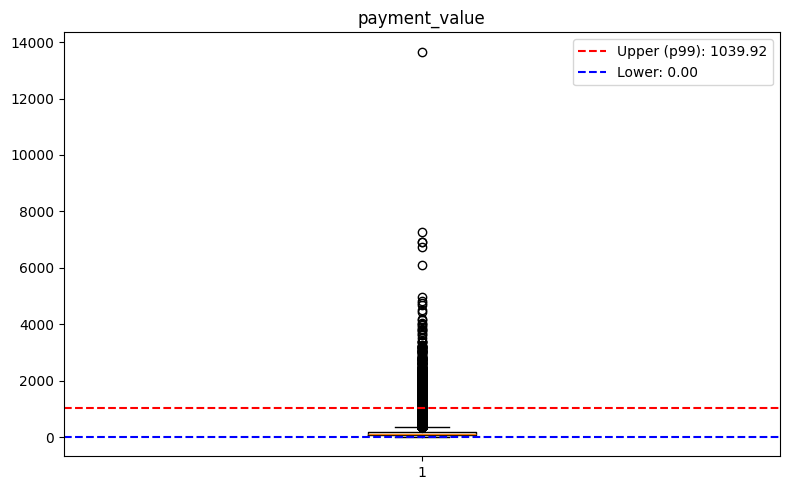

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

lower = 0
upper = order_payments["payment_value"].quantile(0.99)

ax.boxplot(order_payments["payment_value"], vert=True)
ax.axhline(upper, color="red", linestyle="--", label=f"Upper (p99): {upper:.2f}")
ax.axhline(lower, color="blue", linestyle="--", label=f"Lower: {lower:.2f}")
ax.set_title("payment_value")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
upper = order_payments["payment_value"].quantile(0.99)

outliers = (order_payments["payment_value"] > upper).sum()
pct = outliers / len(order_payments) * 100

print(f"payment_value: {outliers} outliers ({pct:.2f}%)")

order_payments["outlier_payment_value"] = order_payments["payment_value"] > upper

payment_value: 1039 outliers (1.00%)


In [ ]:
print("order_id nulls:", int(order_payments["order_id"].isnull().sum()))
print("payment_sequential nulls:", int(order_payments["payment_sequential"].isnull().sum()))
print("payment_type nulls:", int(order_payments["payment_type"].isnull().sum()))
print("payment_installments nulls:", int(order_payments["payment_installments"].isnull().sum()))
print("payment_value nulls:", int(order_payments["payment_value"].isnull().sum()))

order_id nulls: 0
payment_sequential nulls: 0
payment_type nulls: 0
payment_installments nulls: 0
payment_value nulls: 0


## H- Order Reviews:

In [ ]:
order_reviews.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


In [ ]:
print("review_id nulls:", int(order_reviews["review_id"].isnull().sum()))
print("order_id nulls:", int(order_reviews["order_id"].isnull().sum()))
print("review_score nulls:", int(order_reviews["review_score"].isnull().sum()))
print("review_creation_date nulls:", int(order_reviews["review_creation_date"].isnull().sum()))

review_id nulls: 0
order_id nulls: 0
review_score nulls: 0
review_creation_date nulls: 0


In [ ]:
order_reviews.describe(include="all")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,08528f70f579f0c830189efc523d2182,df56136b8031ecd28e200bb18e6ddb2e,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [ ]:
order_reviews["review_score"].unique()

array([4, 5, 1, 3, 2])

We notice many repeated "order_id", which may make sense if we assume that users can make more than one review on the same order. 

We also notice some repeated review_id. This doesn't make sense, because there shouldn't be more than 1 review with the same ID. We may be facing duplicated registrations, so we should analyze this cases to confirm this hypothesis. 


In [ ]:
order_reviews[order_reviews.duplicated(keep=False)].sort_values("review_id")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


There are no full duplicates, so this repetition of IDs is surely caused by a system error. We will flag these so we can considere this when calculating review scores metrics.

In [ ]:
order_reviews["duplicated_review_id"] = order_reviews.duplicated(subset=["review_id"], keep=False)

## I- Product Category Name Translation:

In [ ]:
category_name_translation.head(10)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [ ]:
category_name_translation.describe(include="all")

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [ ]:
print("Category name translation nulls:", int(category_name_translation["product_category_name"].isnull().sum()))
print("product_category_name_english nulls:", int(category_name_translation["product_category_name_english"].isnull().sum()))

Category name translation nulls: 0
product_category_name_english nulls: 0


In [ ]:
import os

output_path = "DATASETS LIMPIOS"
os.makedirs(output_path, exist_ok=True)

orders.to_csv(f"{output_path}/orders.csv", index=False)
customers.to_csv(f"{output_path}/customers.csv", index=False)
order_items.to_csv(f"{output_path}/order_items.csv", index=False)
order_payments.to_csv(f"{output_path}/order_payments.csv", index=False)
order_reviews.to_csv(f"{output_path}/order_reviews.csv", index=False)
products.to_csv(f"{output_path}/products.csv", index=False)
sellers.to_csv(f"{output_path}/sellers.csv", index=False)
geolocation.to_csv(f"{output_path}/geolocation.csv", index=False)
category_name_translation.to_csv(f"{output_path}/category_name_translation.csv", index=False)